In [1]:
from models import load_cnn, load_resnet, load_resnet_transfer
from utils import load_data 
import matplotlib.pyplot as plt 
from sklearn.metrics import confusion_matrix, classification_report
import torch
import seaborn as sns 

def evaluar_modelo(model, test_loader, class_names=None, device='cpu'):
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for (X, y) in test_loader:
            X = X.to(device)
            y = y.to(device)

            outputs = model(X)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(y.cpu().numpy())
    
    cm = confusion_matrix(y_true=all_labels, y_pred=all_preds)
    
    ax = plt.subplot()
    sns.heatmap(cm, cmap='coolwarm', annot=True, fmt='.0f',
                xticklabels=class_names, yticklabels=class_names)
    
    ax.set_ylabel('Real')
    ax.set_xlabel('Pred')

    plt.title('Matriz de Confusion (Test Set)')
    #plt.grid()
    plt.tight_layout()
    plt.show()

    cr = classification_report(y_true=all_labels, y_pred=all_preds, target_names=class_names)

    print(cr)

    return cm


In [2]:
from torchvision.transforms import v2

# ToTensor, ToDtype, Resize, Normalize (Hay que quitar el Data Augmentation)

transform = v2.Compose([
    v2.ToImage(), # ToTensor() PIL IMAGE -> Tensor (H, W, C)
    v2.ToDtype(torch.float32, scale=True), # (C, H, W) [0-255] -> # (C, H, W) [0-1]
    v2.Resize((124, 142)), # necesitamos que todas las imagenes tengan la misma dimension
    v2.Normalize(mean=[0.6940, 0.6538, 0.6292], std=[0.2249, 0.2396, 0.2480]),
])


test_loader = load_data("./test_dataset.csv", transform=transform, batch_size=100)

In [3]:
class_names = []
with open("./class_meaning.csv", 'r', encoding='utf-8') as f:
    lines = f.readlines()
    for line in lines:
        line = line.strip()
        class_names.append(line.split(';')[1])

class_names

['accordion',
 'banjo',
 'drum',
 'flute',
 'guitar',
 'harmonica',
 'saxophone',
 'sitar',
 'tabla',
 'violin']

In [4]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
#best_model = load_cnn('cnn_70.th').to(device)
#best_model = load_resnet('ResNet_67.th').to(device)
best_model = load_resnet_transfer('ResNet50Transfer_90.th').to(device)
print(best_model) # arquitectura del modelo __str__

ResNet50Transfer(
  (base_model): ResNet(
    (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
    (layer1): Sequential(
      (0): Bottleneck(
        (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
        (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (relu): ReLU(inplace=True)
        (downsample): Sequential

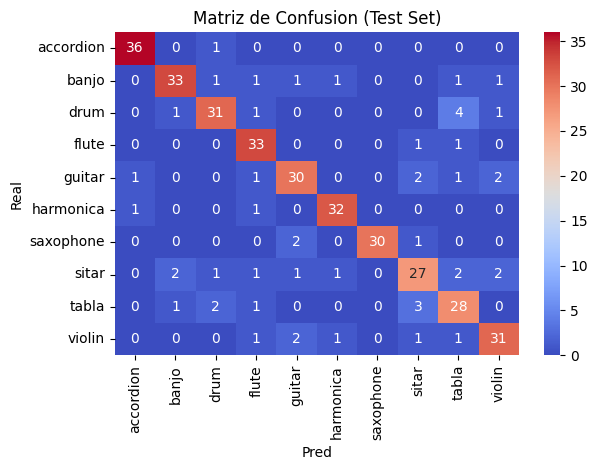

              precision    recall  f1-score   support

   accordion       0.95      0.97      0.96        37
       banjo       0.89      0.85      0.87        39
        drum       0.86      0.82      0.84        38
       flute       0.82      0.94      0.88        35
      guitar       0.83      0.81      0.82        37
   harmonica       0.91      0.94      0.93        34
   saxophone       1.00      0.91      0.95        33
       sitar       0.77      0.73      0.75        37
       tabla       0.74      0.80      0.77        35
      violin       0.84      0.84      0.84        37

    accuracy                           0.86       362
   macro avg       0.86      0.86      0.86       362
weighted avg       0.86      0.86      0.86       362



In [5]:
cm = evaluar_modelo(best_model, test_loader, class_names, device=device)

In [6]:
from torchsummary import summary

summary(best_model, input_size=(3, 140, 162), batch_size=32)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [32, 64, 70, 81]           9,408
       BatchNorm2d-2           [32, 64, 70, 81]             128
              ReLU-3           [32, 64, 70, 81]               0
         MaxPool2d-4           [32, 64, 35, 41]               0
            Conv2d-5           [32, 64, 35, 41]           4,096
       BatchNorm2d-6           [32, 64, 35, 41]             128
              ReLU-7           [32, 64, 35, 41]               0
            Conv2d-8           [32, 64, 35, 41]          36,864
       BatchNorm2d-9           [32, 64, 35, 41]             128
             ReLU-10           [32, 64, 35, 41]               0
           Conv2d-11          [32, 256, 35, 41]          16,384
      BatchNorm2d-12          [32, 256, 35, 41]             512
           Conv2d-13          [32, 256, 35, 41]          16,384
      BatchNorm2d-14          [32, 256,

In [7]:
import torch 
import matplotlib.pyplot as plt

def show_predictions(model, dataloader, class_names, device='cuda', num_images=16):
    model.to(device)
    images_shown = 0

    plt.figure(figsize=(12, 6))

    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            for i in range(images.size(0)):
                if images_shown >= num_images:
                    break

                img = images[i].cpu()
                label = labels[i].item()
                pred = preds[i].item()

                img_np = img.permute(1, 2, 0).numpy()

                # Mostrar imagen con los labels y pred
                plt.subplot(int(num_images**0.5), int(num_images**0.5), images_shown+1)
                if img_np.shape[2] == 3:
                    plt.imshow(img_np)
                else:
                    plt.imshow(img_np, cmap='gray')

                plt.title(f"Real: {class_names[label]}\nPred: {class_names[pred]}")
                plt.axis('off')
                images_shown += 1
            
    plt.tight_layout()
    plt.show()

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.085816..1.4951619].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9738457..1.4951624].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.085816..1.3606051].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.036086..1.4951619].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.9101033..1.4951619].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-3.085816..1.4951619].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.51806..1.3

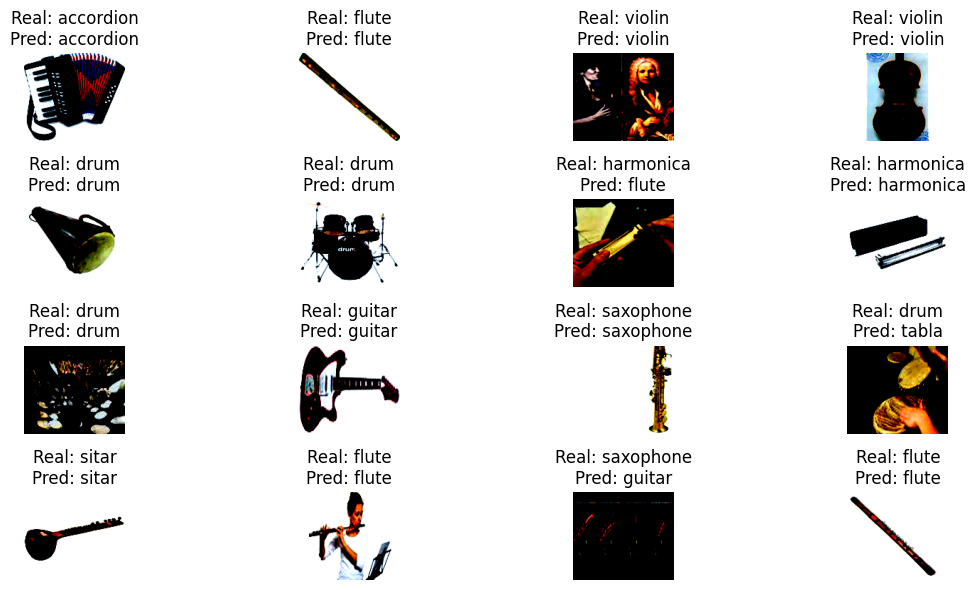

In [8]:
show_predictions(best_model, test_loader, class_names)